# Setup

In [1]:
# Import Libraries

# 1. Filesystem & Reproducibility operations
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
os.environ['ABSL_LOGGING_LEVEL'] = 'error'
import random
import logging
from collections import Counter
from pathlib import Path

# 2. 4 Fondation Libraries
import pandas as pd # manipulate data
import numpy as np # math operations
import matplotlib.pyplot as plt # base visualizations
import seaborn as sns # high level visualizations

# 3. Image Processing (Debugging)
from PIL import Image

# 4. Machine Learning Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve

# 5. Tensorflow (mainly DL_framework)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, regularizers
from sklearn.utils import class_weight

# Reduce TF log noise
tf.get_logger().setLevel(logging.ERROR)

# 6. Pretrained models
from tensorflow.keras.applications import EfficientNetB0, DenseNet121, ResNet50

# 7. Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger

# 8. Data Generator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

E0000 00:00:1777957794.287865      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777957794.347912      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777957794.834551      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777957794.834601      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777957794.834604      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777957794.834606      57 computation_placer.cc:177] computation placer already registered. Please check linka

In [2]:
# Global Configurations
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
print('Versi TensorFlow :', tf.__version__)
print('GPU terdeteksi   :', tf.config.list_physical_devices('GPU'))

Versi TensorFlow : 2.19.0
GPU terdeteksi   : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [4]:
# # Check path dataset
# for dirname, _, _ in os.walk('/kaggle/input/datasets/varpit94/disaster-images-dataset/Comprehensive Disaster Dataset(CDD)'):
#     print(dirname)

# load dataset

In [5]:
paths = []
labels = []

# Mapping Manual
mapping = {
    "Earthquake": 0,
    "Land_Slide": 1,
    "Water_Disaster": 2,
    "Urban_Fire": 3
}

# Base yang akan digunakan untuk search path
base = "/kaggle/input/datasets/varpit94/disaster-images-dataset/Comprehensive Disaster Dataset(CDD)"

# Loop untuk mengambil path dan labeling path images
valid_ext = ('.jpg', '.jpeg', '.png', '.bmp')

for root, dirs, files in os.walk(base):
    for file in files:
        if not file.lower().endswith(valid_ext):
            continue  
        
        path = os.path.join(root, file)

        # ✅ Cek dulu apakah file valid
        try:
            raw = tf.io.read_file(path)
            tf.image.decode_image(raw, channels=3, expand_animations=False)
        except Exception as e:
            print(f"Skipped bad file: {path} -> {e}")
            continue  # skip

        if "Earthquake" in path:
            paths.append(path)
            labels.append(0)
        elif "Land_Slide" in path:
            paths.append(path)
            labels.append(1)
        elif "Water_Disaster" in path:
            paths.append(path)
            labels.append(2)
        elif "Urban_Fire" in path:
            paths.append(path)
            labels.append(3)

# Fungsi 
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (224,224))
    img.set_shape([224, 224, 3])
    return img, label

dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
ds = dataset.shuffle(buffer_size=len(paths), seed=42).map(load_image).batch(32)

print("jumlah images sebelum oversampling : ", len(paths), "images", 
      "\njumlah label sebelum oversampling  : ", len(labels), "labels")

ds

I0000 00:00:1777957822.543973      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777957822.546759      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
Input file read error


Skipped bad file: /kaggle/input/datasets/varpit94/disaster-images-dataset/Comprehensive Disaster Dataset(CDD)/Damaged_Infrastructure/Infrastructure/05_01_0261.png -> {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} jpeg::Uncompress failed. Invalid JPEG data or crop window. [Op:DecodeImage] name: 
Skipped bad file: /kaggle/input/datasets/varpit94/disaster-images-dataset/Comprehensive Disaster Dataset(CDD)/Human_Damage/02_0069.png -> {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
Skipped bad file: /kaggle/input/datasets/varpit94/disaster-images-dataset/Comprehensive Disaster Dataset(CDD)/Fire_Disaster/Urban_Fire/01_01_0060.png -> {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
Skipp

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

# simple eda

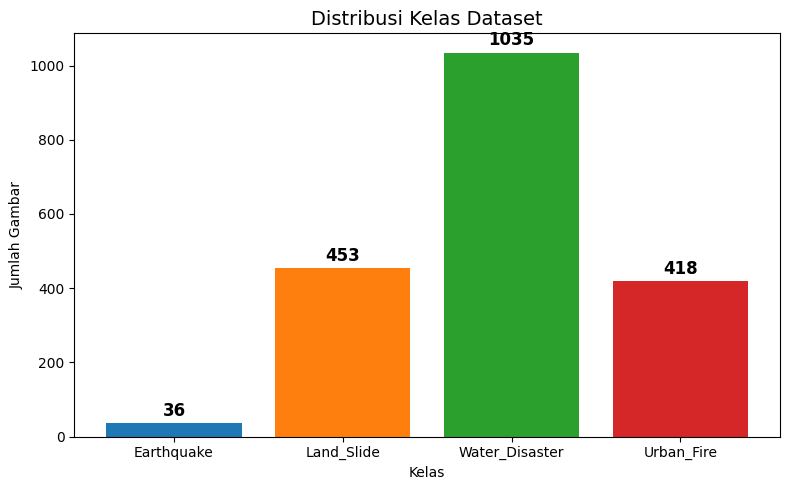

In [6]:
# Hitung jumlah tiap kelas
counter = Counter(labels)
reverse_mapping = {v: k for k, v in mapping.items()}

class_names = [reverse_mapping[i] for i in range(4)]
class_counts = [counter[i] for i in range(4)]

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(class_names, class_counts, color=sns.color_palette("tab10"))

# Tambah angka di atas tiap bar
for bar, count in zip(bars, class_counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
             str(count), ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.title("Distribusi Kelas Dataset", fontsize=14)
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.tight_layout()
plt.show()

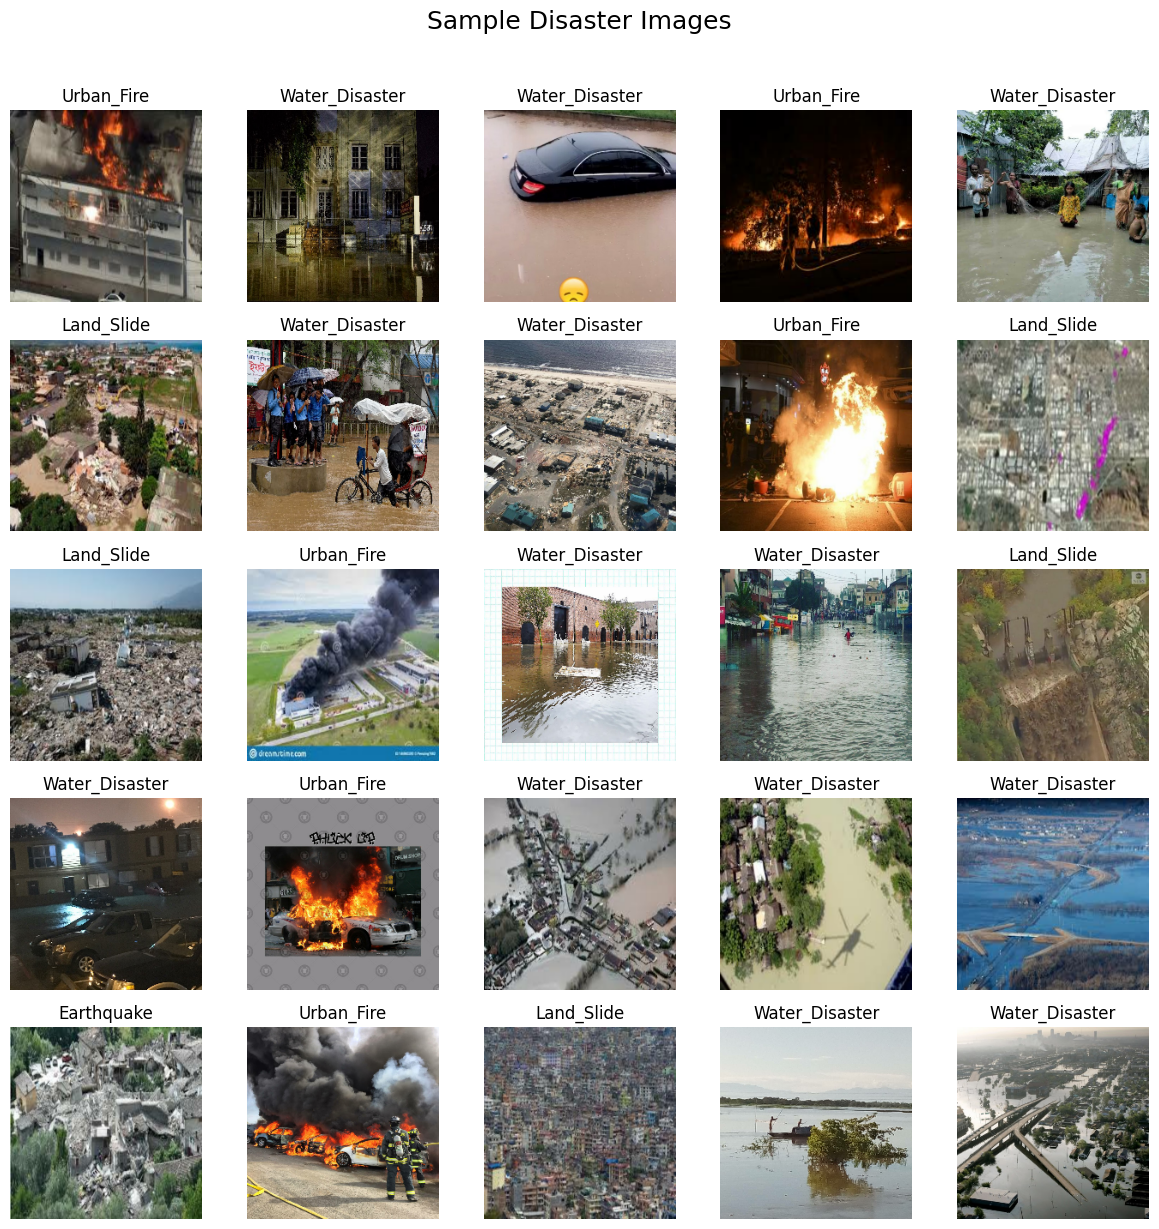

In [7]:
# Ambil 1 batch (32 gambar) dari dataset
sample_images, sample_labels = next(iter(ds))

# Balik mapping biar label angka → nama
reverse_mapping = {v: k for k, v in mapping.items()}
# {0: "Earthquake", 1: "Land_Slide", 2: "Water_Disaster", 3: "Urban_Fire"}

# Tampilkan sampel gambar dengan subplots
plt.figure(figsize=(12, 12))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    
    img = sample_images[i].numpy().astype("uint8")
    label = sample_labels[i].numpy()
    
    plt.imshow(img)
    plt.title(reverse_mapping[label], fontsize=12)
    plt.axis("off")

plt.suptitle("Sample Disaster Images", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

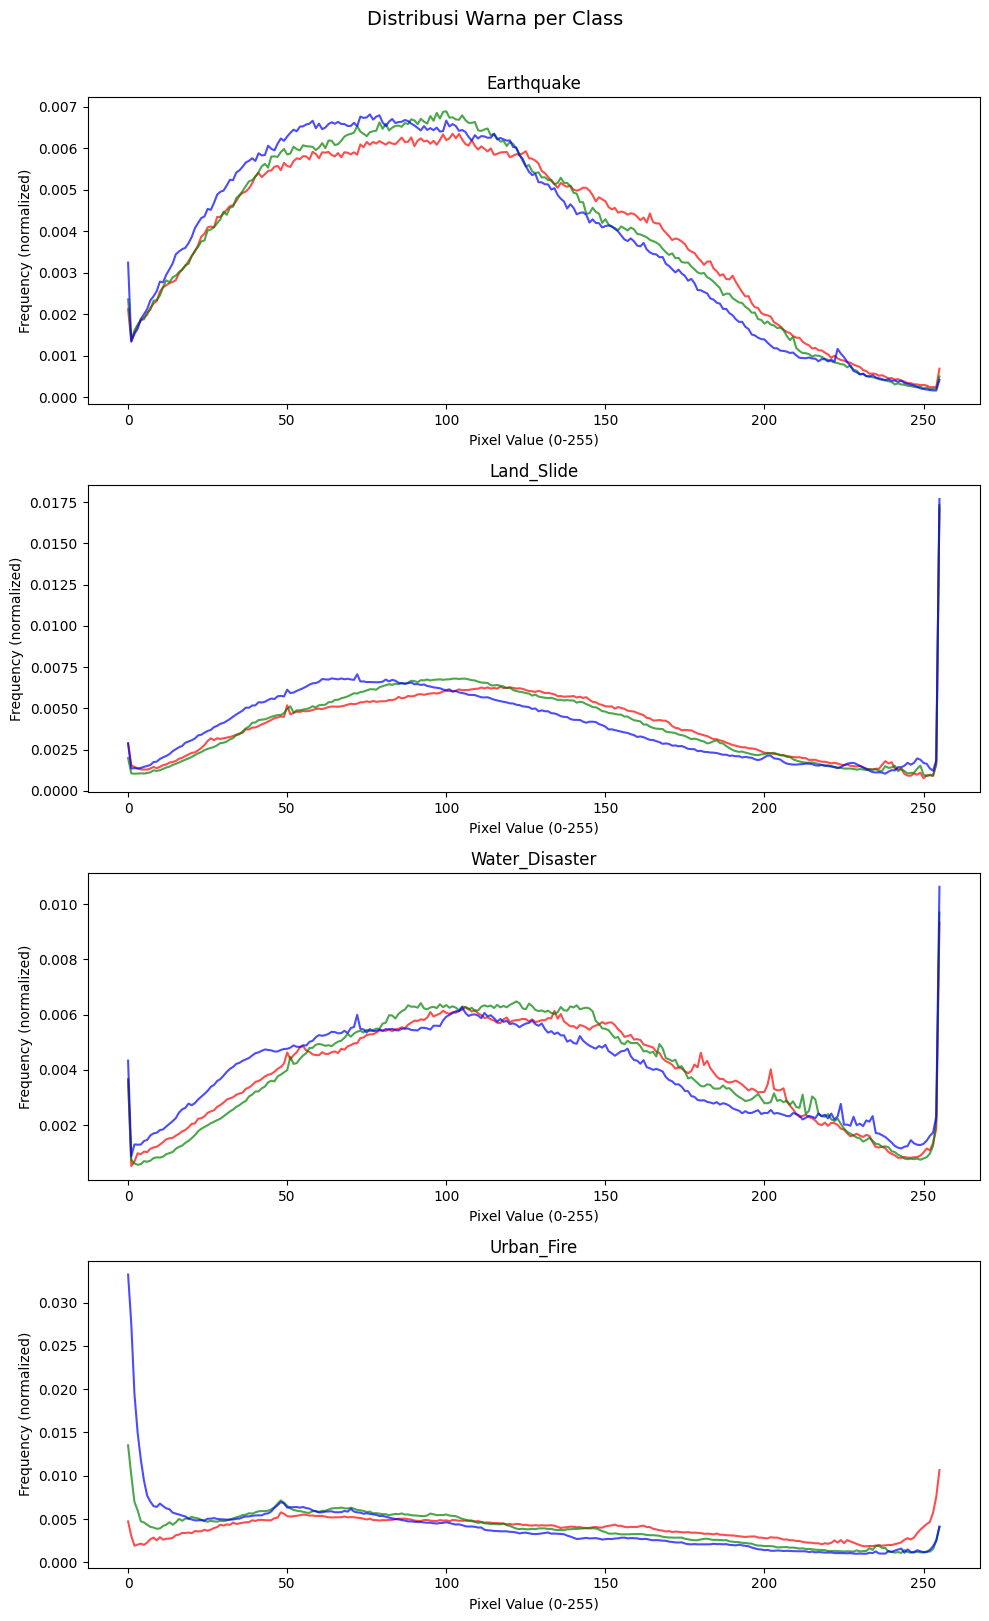

In [8]:
class_names = {0: 'Earthquake', 1: 'Land_Slide', 2: 'Water_Disaster', 3: 'Urban_Fire'}
colors = ['red', 'green', 'blue']
channels = ['R', 'G', 'B']

fig, axes = plt.subplots(4, 1, figsize=(10, 16))

for class_id, class_name in class_names.items():
    ax = axes[class_id]
    
    # Ambil semua path untuk kelas ini (max 100 biar cepat)
    class_paths = [p for p, l in zip(paths, labels) if l == class_id][:100]
    
    # Akumulasi pixel values per channel
    hist_r = np.zeros(256)
    hist_g = np.zeros(256)
    hist_b = np.zeros(256)
    
    for path in class_paths:
        img = np.array(Image.open(path).convert('RGB').resize((224, 224)))
        hist_r += np.bincount(img[:,:,0].flatten(), minlength=256)
        hist_g += np.bincount(img[:,:,1].flatten(), minlength=256)
        hist_b += np.bincount(img[:,:,2].flatten(), minlength=256)
    
    # Normalize
    hist_r /= hist_r.sum()
    hist_g /= hist_g.sum()
    hist_b /= hist_b.sum()
    
    ax.plot(hist_r, color='red', label='R', alpha=0.7)
    ax.plot(hist_g, color='green', label='G', alpha=0.7)
    ax.plot(hist_b, color='blue', label='B', alpha=0.7)
    ax.set_title(f'{class_name}')
    ax.set_xlabel('Pixel Value (0-255)')
    ax.set_ylabel('Frequency (normalized)')

plt.suptitle('Distribusi Warna per Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# split data 

In [9]:
train_paths, test_val_paths, train_labels, test_val_labels = train_test_split(
    paths,
    labels,
    test_size=0.3,
    stratify=labels,
    random_state=42
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    test_val_paths,
    test_val_labels,
    test_size=2/3,
    stratify=test_val_labels,
    random_state=42
)

print("Train size : ", len(train_paths))
print("Val size   : ", len(val_paths))
print("Test size  : ", len(test_paths), "\n")

print(np.unique(train_labels))
print(np.unique(val_labels))
print(np.unique(test_labels))

Train size :  1359
Val size   :  194
Test size  :  389 

[0 1 2 3]
[0 1 2 3]
[0 1 2 3]


In [10]:
def load_image_aug(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    
    # Tambah augmentasi biar gambar duplikat tidak identik
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)

    return img, label  

# Lihat distribusi dulu
print(Counter(train_labels))

train_paths  = np.array(train_paths)
train_labels = np.array(train_labels)

max_count = max(Counter(train_labels).values())

oversampled_paths, oversampled_labels = [], []

for cls in np.unique(train_labels):
    idx = np.where(train_labels == cls)[0]
    repeat = max_count // len(idx)
    remainder = max_count % len(idx)
    
    oversampled_paths  += list(train_paths[idx]) * repeat + list(train_paths[idx][:remainder])
    oversampled_labels += list(train_labels[idx]) * repeat + list(train_labels[idx][:remainder])

oversampled_paths  = np.array(oversampled_paths)
oversampled_labels = np.array(oversampled_labels)

print("Setelah oversampling:", Counter(oversampled_labels))

# Ganti train_ds 
train_ds_oversamp = (
    tf.data.Dataset.from_tensor_slices((
        tf.constant(oversampled_paths,  dtype=tf.string),
        tf.constant(oversampled_labels, dtype=tf.int32)
    ))
    .shuffle(len(oversampled_paths))
    .map(load_image_aug, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

Counter({2: 724, 1: 317, 3: 293, 0: 25})
Setelah oversampling: Counter({np.int64(0): 724, np.int64(1): 724, np.int64(2): 724, np.int64(3): 724})


In [11]:
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (224,224))
    img.set_shape([224, 224, 3])
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels)).map(load_image).batch(32)
val_ds   = tf.data.Dataset.from_tensor_slices((val_paths, val_labels)).map(load_image).batch(32)
test_ds  = tf.data.Dataset.from_tensor_slices((test_paths, test_labels)).map(load_image).batch(32)

# Base Model (Tanpa Oversampling)

## Base Model Architecture

In [12]:
# baseline model
base_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(4, activation='softmax')
])

base_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

base_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,537,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,594,756 (21.34 MB)

 Trainable params: 5,594,756 (21.34 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels 
)
class_weights = dict(enumerate(weights))

## Training Base Model (Tanpa Oversampling)

In [14]:
base_model_history = base_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks,
    class_weight = class_weights,
    verbose=1
)

Epoch 1/50


I0000 00:00:1777957972.877732     110 service.cc:152] XLA service 0x7bfdc0008140 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777957972.877771     110 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777957972.877775     110 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777957973.410510     110 cuda_dnn.cc:529] Loaded cuDNN version 91002


 3/43 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.2292 - loss: 1.6731

I0000 00:00:1777957979.083638     110 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


43/43 ━━━━━━━━━━━━━━━━━━━━ 15s 173ms/step - accuracy: 0.3226 - loss: 1.4447 - val_accuracy: 0.3351 - val_loss: 1.3573 - learning_rate: 0.0010
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.3403 - loss: 1.2414 - val_accuracy: 0.6237 - val_loss: 1.1488 - learning_rate: 0.0010
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.4264 - loss: 1.1707 - val_accuracy: 0.2990 - val_loss: 1.3196 - learning_rate: 0.0010
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.3550 - loss: 1.2215 - val_accuracy: 0.2784 - val_loss: 1.2897 - learning_rate: 0.0010
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4039 - loss: 1.1164
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.4054 - loss: 1.1151 - val_accuracy: 0.3196 - val_loss: 1.3536 - learning_rate: 0.0010
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.4571 - loss: 1.0543 - val_accuracy: 0.5

## Evaluating Base Model (Tanpa Oversampling) 

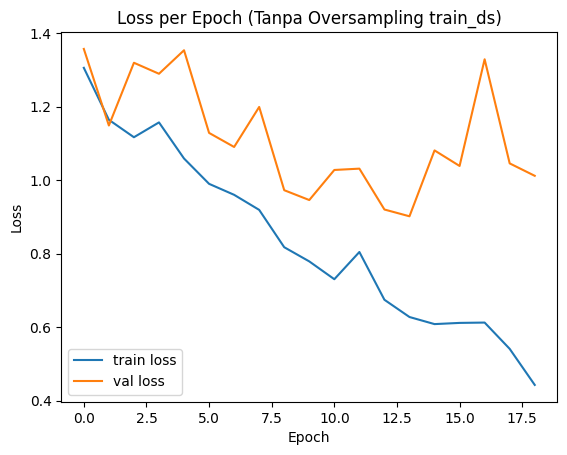

In [15]:
plt.plot(base_model_history.history['loss'], label='train loss')
plt.plot(base_model_history.history['val_loss'], label='val loss')

plt.title('Loss per Epoch (Tanpa Oversampling train_ds)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [44]:
# probabilitas dari model
y_test_pred_probs = base_model.predict(test_ds)

# convert porbabilitas ke integer
y_test_pred = np.argmax(y_test_pred_probs, axis = 1)

# ambil label dari dataset
y_test_true = []
for images, label in test_ds:
    y_test_true.extend(label.numpy())

y_test_true = np.array(y_test_true)

class_name = ['Earthquake', 'Land_Slide', 'Water_Disaster', 'Urban_Fire']

print("Classfication Report Base Model tanpa Oversampling pada train_ds")
print("-"*55)
print(classification_report(y_test_true, y_test_pred, target_names = class_name))
print("-"*55)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step
Classfication Report Base Model tanpa Oversampling pada train_ds
-------------------------------------------------------
                precision    recall  f1-score   support

    Earthquake       0.08      0.14      0.10         7
    Land_Slide       0.51      0.48      0.49        91
Water_Disaster       0.75      0.71      0.73       208
    Urban_Fire       0.64      0.71      0.67        83

      accuracy                           0.65       389
     macro avg       0.49      0.51      0.50       389
  weighted avg       0.66      0.65      0.65       389

-------------------------------------------------------


# Base Model (Oversampling)

## Base Model Architecture

In [17]:
# baseline model
test_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(4, activation='softmax')
])

test_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

test_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     5,537,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,594,756 (21.34 MB)

 Trainable params: 5,594,756 (21.34 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

## Training Base Model (Oversampling)

In [19]:
base_model_oversamp_history = test_model.fit(
    train_ds_oversamp,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - accuracy: 0.3562 - loss: 1.4076 - val_accuracy: 0.5825 - val_loss: 1.2576 - learning_rate: 0.0010
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.5613 - loss: 0.9951 - val_accuracy: 0.6289 - val_loss: 0.9601 - learning_rate: 0.0010
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.7103 - loss: 0.7275 - val_accuracy: 0.6546 - val_loss: 1.0287 - learning_rate: 0.0010
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.7818 - loss: 0.5757 - val_accuracy: 0.6289 - val_loss: 0.8602 - learning_rate: 0.0010
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.8177 - loss: 0.4979 - val_accuracy: 0.7010 - val_loss: 0.8677 - learning_rate: 0.0010
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.8407 - loss: 0.4435 - val_accuracy: 0.6907 - val_loss: 0.8380 - learning_rate: 0.0010
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.8581 - loss: 0.3858 - val_ac

## Evaluating Base Model (Oversampling)

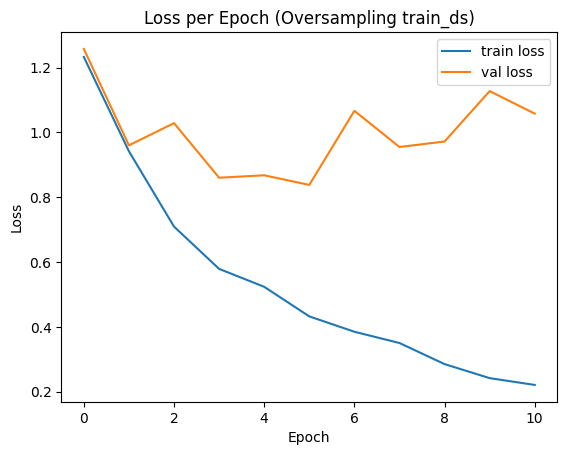

In [20]:
plt.plot(base_model_oversamp_history.history['loss'], label='train loss')
plt.plot(base_model_oversamp_history.history['val_loss'], label='val loss')

plt.title('Loss per Epoch (Oversampling train_ds)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [43]:
# probabilitas dari model
y_test_pred_probs = test_model.predict(test_ds)

# convert porbabilitas ke integer
y_test_pred = np.argmax(y_test_pred_probs, axis = 1)

# ambil label dari dataset
y_test_true = []
for images, label in test_ds:
    y_test_true.extend(label.numpy())

y_test_true = np.array(y_test_true)

class_name = ['Earthquake', 'Land_Slide', 'Water_Disaster', 'Urban_Fire']

print("Classfication Report Base Model dengan Oversampling pada train_ds")
print("-"*55)
print(classification_report(y_test_true, y_test_pred, target_names = class_name))
print("-"*55)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
Classfication Report Base Model dengan Oversampling pada train_ds
-------------------------------------------------------
                precision    recall  f1-score   support

    Earthquake       0.12      0.14      0.13         7
    Land_Slide       0.59      0.48      0.53        91
Water_Disaster       0.75      0.80      0.77       208
    Urban_Fire       0.77      0.80      0.78        83

      accuracy                           0.71       389
     macro avg       0.56      0.55      0.56       389
  weighted avg       0.71      0.71      0.71       389

-------------------------------------------------------


## Interpretasi Keseluruhan Base Model

### Model 1 — Tanpa Oversampling

**Classification Report:**
- Accuracy 0.65, Weighted F1 0.65 — performa cukup untuk baseline sederhana
- `Water_Disaster` F1 0.73 dan `Urban_Fire` F1 0.67 — dua kelas dengan data terbanyak sudah cukup baik dikenali
- `Land_Slide` F1 0.49 — model mulai mengenali tapi masih belum optimal, kemungkinan masih terdampak imbalance
- `Earthquake` F1 0.10 — konsisten buruk di semua run karena test set hanya 7 sampel, tidak bisa dijadikan acuan

**Loss Curve:**
- Train loss turun konsisten dan mulus dari 1.31 → 0.44 selama 19 epoch
- Val loss juga turun secara umum dari 1.37 → 1.01, tapi sangat zig-zag dan spike di beberapa epoch
- Gap antara train (0.44) dan val (1.01) di akhir cukup lebar — **mild overfitting**
- Instabilitas val loss menunjukkan model belum bisa generalize secara konsisten

**Kesimpulan Model 1:** Model mampu belajar pola dasar, namun performa terbatas akibat imbalance data. Kelas minoritas seperti `Land_Slide` dan `Earthquake` masih sulit diprediksi dengan baik. Val loss yang zig-zag menandakan model sensitif terhadap distribusi batch dan belum stabil.

---

### Model 2 — Dengan Oversampling

**Classification Report:**
- Accuracy 0.71, Weighted F1 0.71 — peningkatan signifikan dan konsisten dari Model 1
- `Water_Disaster` F1 naik ke 0.77 dan `Urban_Fire` ke 0.78 — dua kelas terkuat model
- `Land_Slide` F1 0.53 — oversampling berhasil bantu kelas ini, naik dari 0.49
- `Earthquake` F1 0.13 — sedikit naik tapi tetap tidak representatif karena support hanya 7 sampel

**Loss Curve:**
- Train loss turun sangat agresif dan mulus dari 1.25 → 0.22 hanya dalam 10 epoch
- Val loss stagnan di rentang 0.85–1.07 sejak epoch 3 dan mulai naik di akhir
- Gap train vs val terus melebar sejak epoch 2 — **overfitting klasik**
- Model menghafal pola duplikat hasil oversample sehingga tidak generalize optimal ke data baru

**Kesimpulan Model 2:** Oversampling berhasil meningkatkan performa evaluasi secara keseluruhan, terbukti konsisten di dua kali run dengan selisih +0.06 di semua metric. Namun loss curve menunjukkan model mulai menghafal data training, yang mengindikasikan kapasitas arsitektur BencNet sudah mentok.

---

## Perbandingan Keseluruhan

| Metric | Tanpa OS | Dengan OS |
|---|---|---|
| Accuracy | 0.65 | **0.71** |
| Macro F1 | 0.50 | **0.56** |
| Weighted F1 | 0.65 | **0.71** |
| Train loss akhir | 0.44 | 0.22 |
| Val loss akhir | 1.01 | 1.06 |
| Kondisi | Mild overfitting | Overfitting |
| Stabilitas val | Zig-zag tapi turun | Stagnan lalu naik |

---

## Keputusan: Lanjut ke Transfer Learning dengan Oversampling ✅

Selisih konsisten +0.06 di semua metric antara dua run yang berbeda menunjukkan oversampling memberikan kontribusi nyata, bukan sekadar kebetulan randomness. Overfitting yang terjadi bukan kesalahan oversampling, melainkan sinyal bahwa **arsitektur BencNet sudah mencapai batas kapasitasnya**.

Transfer learning dengan EfficientNetB0 adalah solusi yang tepat karena:
- Backbone pretrained sudah memiliki fitur kaya dari ImageNet sehingga tidak perlu bergantung pada duplikat data untuk belajar pola
- Overfitting dapat dikontrol dengan `Dropout`, `EarlyStopping`, dan fine-tuning yang hati-hati
- Kelas yang sudah membaik dengan oversampling seperti `Land_Slide` berpotensi meningkat lebih signifikan lagi dengan fitur yang lebih powerful

**Yang perlu diperhatikan di transfer learning:**
- Tetap pakai oversampling pada train_ds
- Pastikan tidak ada double normalisasi di `load_image_aug` karena `preprocess_input` EfficientNet expects input 0–255
- Pakai `EarlyStopping` dengan `restore_best_weights=True` untuk cegah overfitting lebih awal
- Monitor gap train vs val loss lebih ketat, terutama saat phase 2 fine-tuning

# Model + Transfer Learning

## EfficientNetB0 Architecture (237 Layers)

In [22]:
base = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
base.trainable = False

model_effnetb0 = models.Sequential([
    layers.Lambda(tf.keras.applications.efficientnet.preprocess_input,
                  input_shape=(224, 224, 3)),
    base,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.4),
    layers.Dense(4, activation='softmax')
])

model_effnetb0.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_effnetb0.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,219,175 (16.09 MB)

 Trainable params: 167,044 (652.52 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

## Hyperparameter Tuning (2 Phases)

In [23]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose = 1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_effnet.keras', monitor='val_loss', save_best_only=True
    )
]

history_phase1 = model_effnetb0.fit(
    train_ds_oversamp,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 63s 402ms/step - accuracy: 0.7316 - loss: 0.9981 - val_accuracy: 0.8402 - val_loss: 0.7264 - learning_rate: 0.0010
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.9032 - loss: 0.4954 - val_accuracy: 0.8454 - val_loss: 0.6642 - learning_rate: 0.0010
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.9396 - loss: 0.4142 - val_accuracy: 0.8814 - val_loss: 0.6843 - learning_rate: 0.0010
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9538 - loss: 0.3597 - val_accuracy: 0.8557 - val_loss: 0.7420 - learning_rate: 0.0010
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.9621 - loss: 0.3392 - val_accuracy: 0.8454 - val_loss: 0.7487 - learning_rate: 0.0010
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.9597 - loss: 0.3333 - val_accuracy: 0.8557 - val_loss: 0.7540 - learning_rate: 5.0000e-04
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.9682 - loss: 0.3119 - v

In [24]:
# Unfreeze 90 layer terakhir EfficientNetB0
base.trainable = True
for layer in base.layers[:-90]:
    layer.trainable = False

# Compile ulang dengan LR kecil
model_effnetb0.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model_effnetb0.fit(
    train_ds_oversamp,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 73s 392ms/step - accuracy: 0.6955 - loss: 1.0520 - val_accuracy: 0.8557 - val_loss: 0.6820 - learning_rate: 1.0000e-05
Epoch 2/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.7945 - loss: 0.7568 - val_accuracy: 0.8247 - val_loss: 0.7370 - learning_rate: 1.0000e-05
Epoch 3/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.8459 - loss: 0.6228 - val_accuracy: 0.8144 - val_loss: 0.7540 - learning_rate: 1.0000e-05
Epoch 4/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8600 - loss: 0.5922 - val_accuracy: 0.8144 - val_loss: 0.7611 - learning_rate: 1.0000e-05
Epoch 5/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8777 - loss: 0.5525 - val_accuracy: 0.8144 - val_loss: 0.7651 - learning_rate: 5.0000e-06
Epoch 6/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8924 - loss: 0.5367 - val_accuracy: 0.8247 - val_loss: 0.7618 - learning_rate: 5.0000e-06
Epoch 6: early stopping
Restoring model weights from the end of the 

## Evaluating EfficientNetB0

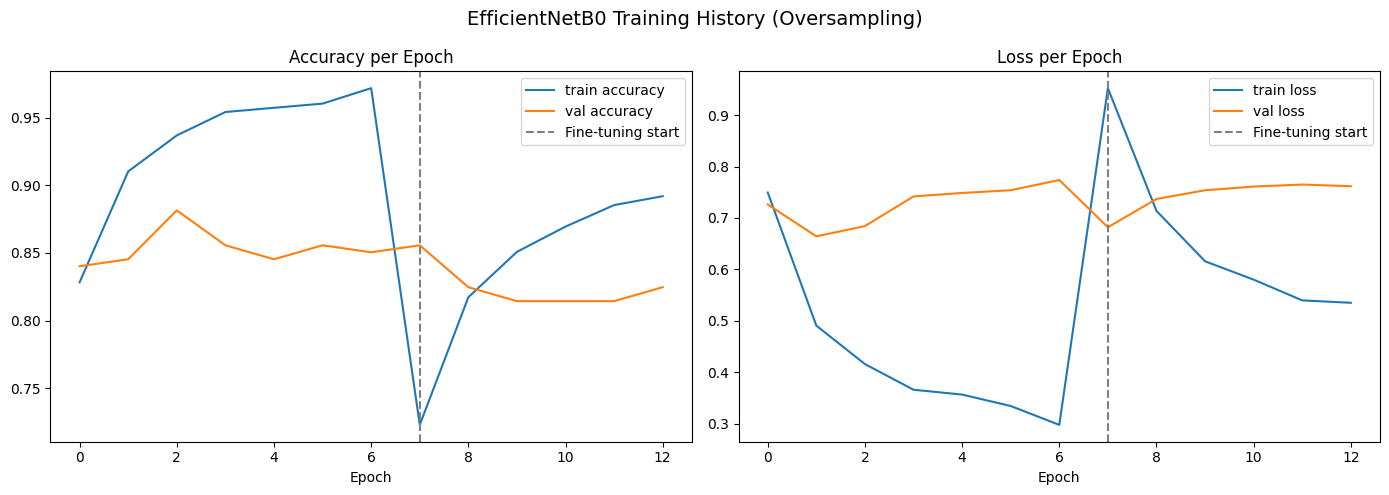

In [46]:
# Gabungkan history
acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']
loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

# Titik pemisah phase 1 & 2
phase1_end = len(history_phase1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(acc, label='train accuracy')
axes[0].plot(val_acc, label='val accuracy')
axes[0].axvline(x=phase1_end, color='gray', linestyle='--', label='Fine-tuning start')
axes[0].set_title('Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Loss
axes[1].plot(loss, label='train loss')
axes[1].plot(val_loss, label='val loss')
axes[1].axvline(x=phase1_end, color='gray', linestyle='--', label='Fine-tuning start')
axes[1].set_title('Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('EfficientNetB0 Training History (Oversampling)', fontsize=14)
plt.tight_layout()
plt.show()

In [45]:
y_pred_probs = model_effnetb0.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = []
for images, batch_labels in test_ds:
    y_true.extend(batch_labels.numpy())
y_true = np.array(y_true)

class_names = ['Earthquake', 'Land_Slide', 'Water_Disaster', 'Urban_Fire']

print("Classification Report EfficientNetB0 dengan Oversampling")
print("-"*55)
print(classification_report(y_true, y_pred, target_names=class_names))
print("-"*55)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step
Classification Report EfficientNetB0 dengan Oversampling
-------------------------------------------------------
                precision    recall  f1-score   support

    Earthquake       0.08      0.14      0.10         7
    Land_Slide       0.67      0.71      0.69        91
Water_Disaster       0.91      0.85      0.88       208
    Urban_Fire       0.88      0.90      0.89        83

      accuracy                           0.81       389
     macro avg       0.63      0.65      0.64       389
  weighted avg       0.83      0.81      0.82       389

-------------------------------------------------------


# Model + Transfer Learning (Tanpa Oversampling)

## EfficientNetB0 Architecture (237 Layers)

In [29]:
base = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
base.trainable = False

model_effnetb0_temp = models.Sequential([
    layers.Lambda(tf.keras.applications.efficientnet.preprocess_input,
                  input_shape=(224, 224, 3)),
    base,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.4),
    layers.Dense(4, activation='softmax')
])

model_effnetb0_temp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_effnetb0_temp.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,219,175 (16.09 MB)

 Trainable params: 167,044 (652.52 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

## Hyperparameter Tuning (2 Phases)

In [30]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose = 1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_effnet.keras', monitor='val_loss', save_best_only=True
    )
]

history_phase1_temp = model_effnetb0_temp.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight= class_weights,
    callbacks=callbacks
)

Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 49s 700ms/step - accuracy: 0.5061 - loss: 1.6728 - val_accuracy: 0.8196 - val_loss: 0.7708 - learning_rate: 0.0010
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.8226 - loss: 0.7718 - val_accuracy: 0.8299 - val_loss: 0.6661 - learning_rate: 0.0010
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.8834 - loss: 0.5867 - val_accuracy: 0.8608 - val_loss: 0.6448 - learning_rate: 0.0010
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.8923 - loss: 0.5495 - val_accuracy: 0.8608 - val_loss: 0.6533 - learning_rate: 0.0010
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.9164 - loss: 0.5345 - val_accuracy: 0.8763 - val_loss: 0.6670 - learning_rate: 0.0010
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9102 - loss: 0.4599 - val_accuracy: 0.8505 - val_loss: 0.6867 - learning_rate: 0.0010
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9463 - loss: 0.3925 - val_a

In [31]:
# Unfreeze 90 layer terakhir EfficientNetB0
base.trainable = True
for layer in base.layers[:-90]:
    layer.trainable = False

# Compile ulang dengan LR kecil
model_effnetb0_temp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2_temp = model_effnetb0_temp.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight= class_weights,
    callbacks=callbacks
)

Epoch 1/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 70s 772ms/step - accuracy: 0.7462 - loss: 1.2199 - val_accuracy: 0.8557 - val_loss: 0.6512 - learning_rate: 1.0000e-05
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.7578 - loss: 1.1363 - val_accuracy: 0.8505 - val_loss: 0.6695 - learning_rate: 1.0000e-05
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.7898 - loss: 0.8410 - val_accuracy: 0.8196 - val_loss: 0.7027 - learning_rate: 1.0000e-05
Epoch 4/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.7824 - loss: 0.8512 - val_accuracy: 0.8144 - val_loss: 0.7311 - learning_rate: 1.0000e-05
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.7807 - loss: 0.7918 - val_accuracy: 0.8093 - val_loss: 0.7605 - learning_rate: 5.0000e-06
Epoch 6/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.7937 - loss: 0.7643 - val_accuracy: 0.7938 - val_loss: 0.7821 - learning_rate: 5.0000e-06
Epoch 6: early stopping
Restoring model weights from the end of the 

## Evaluating EfficientNetB0 (Tanpa Oversampling)

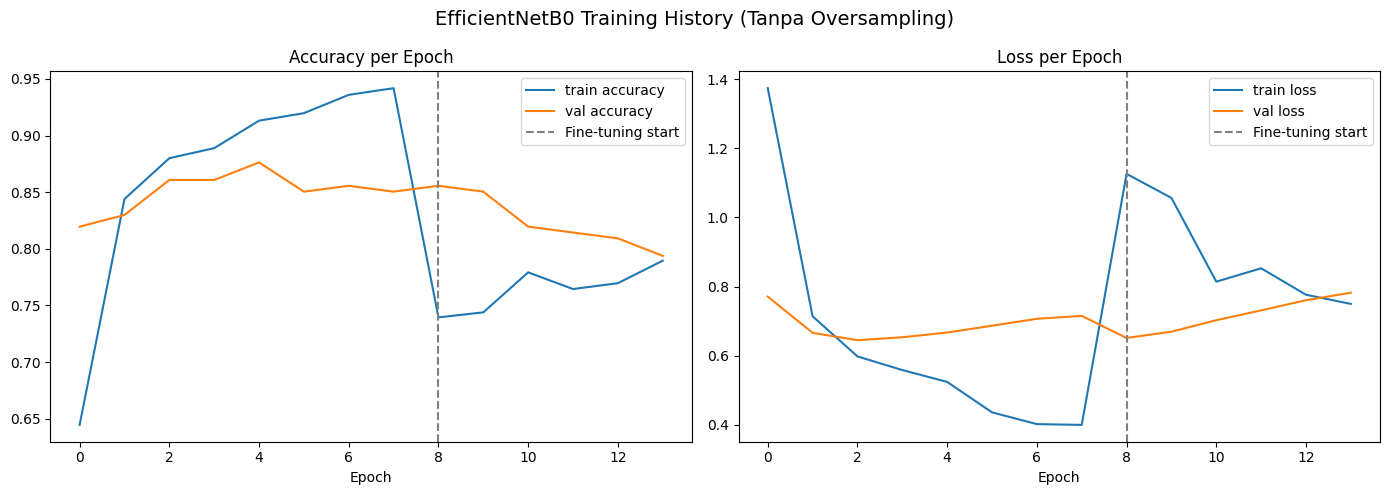

In [47]:
# Gabungkan history
acc = history_phase1_temp.history['accuracy'] + history_phase2_temp.history['accuracy']
val_acc = history_phase1_temp.history['val_accuracy'] + history_phase2_temp.history['val_accuracy']
loss = history_phase1_temp.history['loss'] + history_phase2_temp.history['loss']
val_loss = history_phase1_temp.history['val_loss'] + history_phase2_temp.history['val_loss']

# Titik pemisah phase 1 & 2
phase1_end_temp = len(history_phase1_temp.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(acc, label='train accuracy')
axes[0].plot(val_acc, label='val accuracy')
axes[0].axvline(x=phase1_end_temp, color='gray', linestyle='--', label='Fine-tuning start')
axes[0].set_title('Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Loss
axes[1].plot(loss, label='train loss')
axes[1].plot(val_loss, label='val loss')
axes[1].axvline(x=phase1_end_temp, color='gray', linestyle='--', label='Fine-tuning start')
axes[1].set_title('Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('EfficientNetB0 Training History (Tanpa Oversampling)', fontsize=14)
plt.tight_layout()
plt.show()

In [48]:
y_pred_probs = model_effnetb0_temp.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = []
for images, batch_labels in test_ds:
    y_true.extend(batch_labels.numpy())
y_true = np.array(y_true)

class_names = ['Earthquake', 'Land_Slide', 'Water_Disaster', 'Urban_Fire']

print("Classification Report EfficientNetB0 tanpa Oversampling")
print("-"*55)
print(classification_report(y_true, y_pred, target_names=class_names))
print("-"*55)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
Classification Report EfficientNetB0 tanpa Oversampling
-------------------------------------------------------
                precision    recall  f1-score   support

    Earthquake       0.18      0.57      0.28         7
    Land_Slide       0.76      0.69      0.72        91
Water_Disaster       0.92      0.88      0.90       208
    Urban_Fire       0.90      0.92      0.91        83

      accuracy                           0.84       389
     macro avg       0.69      0.77      0.70       389
  weighted avg       0.87      0.84      0.85       389

-------------------------------------------------------


## Interpretasi EfficientNetB0

### EfficientNetB0 dengan Oversampling

**Classification Report:**
- Accuracy 0.81, Weighted F1 0.82 — lompatan besar dari BencNet (0.71)
- `Water_Disaster` F1 0.88 dan `Urban_Fire` F1 0.89 — sangat baik, model sangat percaya diri di dua kelas ini
- `Land_Slide` F1 naik signifikan ke 0.69 dari 0.53 di BencNet — transfer learning terbukti bantu kelas ini
- `Earthquake` F1 0.10 — tidak ada improvement, konsisten buruk karena memang data test hanya 7 sampel

**Loss Curve:**
- **Phase 1 (epoch 0–6):** Train accuracy naik mulus dari 0.83 → 0.97, val accuracy stabil di 0.85–0.88. Train loss turun agresif ke 0.30, val loss stagnan di 0.70–0.77. Gap sudah mulai lebar — overfitting ringan tapi performa val masih bagus
- **Phase 2 (setelah garis putus):** Ada drop tajam di epoch 7 — train accuracy anjlok ke 0.73, train loss melonjak ke 0.97. Ini normal saat fine-tuning dimulai karena learning rate berubah dan layer baru dibuka
- **Recovery phase 2:** Train accuracy naik kembali ke 0.89, tapi val accuracy justru turun ke 0.82. Gap melebar lagi — **overfitting di phase 2**, fine-tuning terlalu agresif menggeser weight pretrained

**Kesimpulan:** Oversampling + EfficientNetB0 sudah jauh lebih baik dari BencNet. Phase 1 solid, tapi fine-tuning di phase 2 belum optimal — val accuracy malah turun dari phase 1.

---

### EfficientNetB0 tanpa Oversampling

**Classification Report:**
- Accuracy 0.84, Weighted F1 0.85 — **terbaik dari semua model yang diuji**
- `Water_Disaster` F1 0.90 dan `Urban_Fire` F1 0.91 — hampir sempurna untuk dua kelas ini
- `Land_Slide` F1 0.72 — lebih tinggi dari versi oversampling (0.69), mengejutkan
- `Earthquake` F1 0.28 — jauh lebih baik dari semua model sebelumnya, precision 0.18 tapi recall 0.57 menunjukkan model mulai bisa menangkap kelas ini meski masih terbatas

**Loss Curve:**
- **Phase 1 (epoch 0–7):** Train accuracy naik dari 0.65 → 0.94, val accuracy naik beriringan dari 0.82 → 0.87. Train loss turun konsisten ke 0.40, val loss turun ke 0.63. Gap kecil dan keduanya konvergen — **fase terbaik, tidak overfitting**
- **Phase 2 (setelah garis putus):** Drop tajam di epoch 8 sama seperti versi oversampling — normal saat fine-tuning dimulai
- **Recovery phase 2:** Train accuracy naik ke 0.79, val accuracy turun ke 0.79 — keduanya bertemu di titik yang sama, gap mengecil. Val loss mulai naik tipis tapi masih terkontrol — **overfitting ringan, lebih stabil dari versi oversampling**

**Kesimpulan:** Tanpa oversampling, EfficientNetB0 justru lebih stabil dan menghasilkan performa terbaik. Phase 1 sangat bersih tanpa overfitting, fine-tuning di phase 2 lebih terkontrol.

---

## Perbandingan Keseluruhan Semua Model

| Metric | BencNet (OS) | BencNet | EffNetB0 (OS) | EffNetB0 |
|---|---|---|---|---|
| Accuracy | 0.71 | 0.65 | 0.81 | **0.84** |
| Macro F1 | 0.56 | 0.50 | 0.64 | **0.70** |
| Weighted F1 | 0.71 | 0.65 | 0.82 | **0.85** |
| Land_Slide F1 | 0.53 | 0.49 | 0.69 | **0.72** |
| Urban_Fire F1 | 0.78 | 0.67 | 0.89 | **0.91** |
| Kondisi | Overfit | Mild overfit | Overfit phase 2 | Stabil |

---

## Insight Menarik: Oversampling Berbalik di Transfer Learning

Di BencNet, oversampling konsisten lebih baik +0.06 di semua metric. Tapi di EfficientNetB0 justru sebaliknya — **tanpa oversampling lebih unggul di semua metric**. Ini terjadi karena:

- Backbone pretrained ImageNet sudah memiliki representasi fitur yang sangat kaya, sehingga model tidak perlu melihat banyak duplikat untuk belajar pola kelas minoritas
- Oversampling menambah noise dari duplikat gambar yang justru mengganggu proses fine-tuning weight pretrained yang sudah bagus
- Tanpa oversampling, distribusi data lebih natural sehingga model belajar decision boundary yang lebih realistis

## Keputusan Final: EfficientNetB0 Tanpa Oversampling ✅

Model terbaik adalah **EfficientNetB0 tanpa oversampling** dengan accuracy 0.84 dan weighted F1 0.85. Loss curve yang stabil di phase 1 dan fine-tuning yang terkontrol di phase 2 menunjukkan model ini paling siap untuk digunakan, dengan catatan fine-tuning phase 2 masih bisa dioptimalkan lebih lanjut dengan learning rate yang lebih kecil atau jumlah layer yang dibuka lebih sedikit.